# Figure 2 — Model architecture

Schematic of the JAISP joint Rubin+Euclid foundation model and its downstream heads.

**Top tier:** self-supervised *masked-band autoencoding* — a two-stream mixed-resolution
encoder (per-band conv stems -> concat-fuse per instrument -> ConvNeXt downblocks converging
at a 0.4"/px fused scale) feeds a transformer bottleneck; per-stream decoders reconstruct the
held-out band. **Bottom tier:** the frozen encoder transfers to a CenterNet detection head and
a latent astrometry head.

Architecture from `models/jaisp_foundation_v10.py`, `models/detection/centernet_detector.py`,
`models/astrometry2/latent_position_head.py`. Saves to `paper/figures/fig2_architecture.png`.

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import matplotlib.patheffects as pe
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

def find_repo_root():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'data').is_dir() and (c / 'paper').is_dir():
            return c
    raise RuntimeError('repo root not found')

REPO = find_repo_root()
FIGDIR = REPO / 'paper' / 'figures'; FIGDIR.mkdir(exist_ok=True)
ECDFS = REPO / 'data' / 'euclid_tiles_all'
RUBIN_DIR = REPO / 'data' / 'rubin_tiles_all'
CUTOUT_TILE = 'tile_x02816_y02560_tract5063_patch_14'   # same matched tile as Fig. 1

# --- load real band thumbnails for the input stack (consistency with Fig. 1) ---
FOV = 24.0   # arcsec, small thumbnails
def ccrop(a, ps):
    h = int(round(FOV / ps / 2)); c0, c1 = a.shape[0] // 2, a.shape[1] // 2
    return a[c0 - h:c0 + h, c1 - h:c1 + h]
def stretched(img):
    n = ImageNormalize(img, interval=PercentileInterval(99.3), stretch=AsinhStretch(0.1))
    return n(img)

rub = np.load(RUBIN_DIR / f'{CUTOUT_TILE}.npz', allow_pickle=True)
euc = np.load(ECDFS / f'{CUTOUT_TILE}_euclid.npz', allow_pickle=True)
thumbs = {}
for bi, b in enumerate(rub['bands'].tolist()):
    thumbs[b] = stretched(ccrop(np.asarray(rub['img'][bi], np.float32), 0.2))
for b in ['VIS', 'Y', 'J', 'H']:
    thumbs[b] = stretched(ccrop(np.asarray(euc[f'img_{b}'], np.float32), float(euc[f'pixel_scale_{b}'])))
RUBIN_BANDS = ['u', 'g', 'r', 'i', 'z', 'y']
EUCLID_BANDS = ['VIS', 'Y', 'J', 'H']
print('loaded thumbnails:', list(thumbs))

loaded thumbnails: ['u', 'g', 'r', 'i', 'z', 'y', 'VIS', 'Y', 'J', 'H']


saved /home/shemmati/Work/Projects/JAISP/paper/figures/fig2_architecture.png


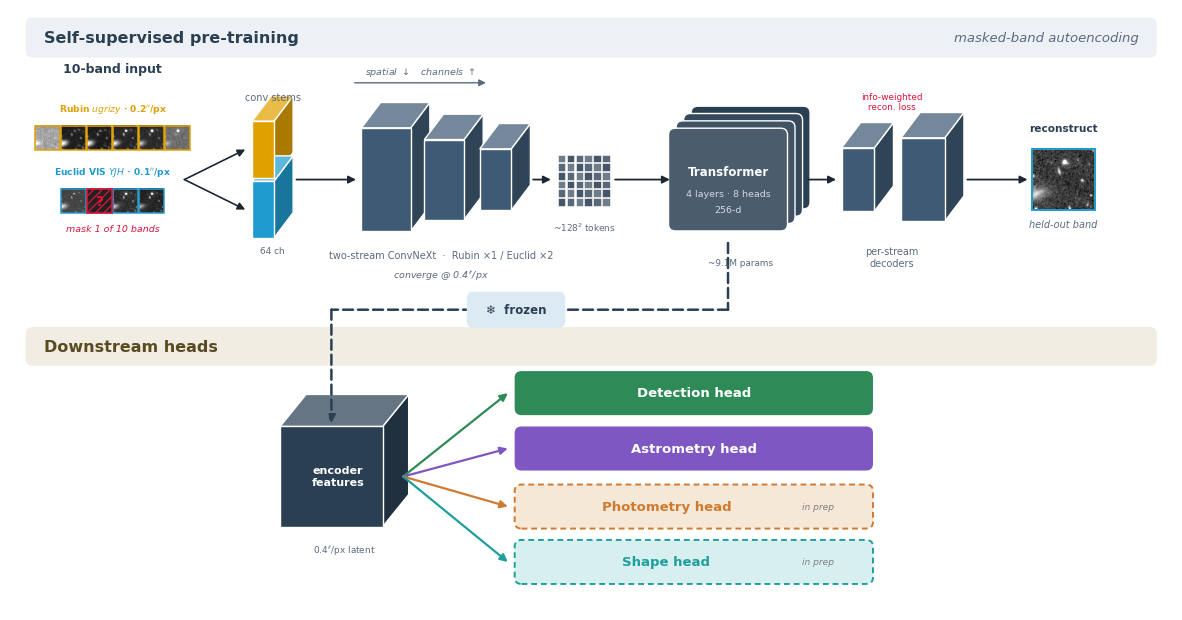

In [2]:
# ============================ Figure 2: architecture schematic ============================
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon

# disciplined palette: deep navy spine + two instrument accents + muted task colors
C_RUBIN = '#e0a000'; C_EUCLID = '#1f9bcf'
C_STEEL = '#3f5a74'; C_BOTL = '#2b3f53'
C_DET = '#2e8b57'; C_AST = '#7e57c2'; C_PHOT = '#cf7a30'; C_SHAPE = '#1f9e9e'
INK = '#1c2733'; SUB = '#5a6b7e'

def shade(c, f):
    r, g, b = mcolors.to_rgb(c)
    if f >= 0:
        return (r + (1-r)*f, g + (1-g)*f, b + (1-b)*f)
    f = -f
    return (r*(1-f), g*(1-f), b*(1-f))

DD = (0.28, 0.38)   # isometric depth vector
def slab(ax, cx, cy, w, h, fc, ec='white', lw=1.0, z=3, dd=DD):
    """3D feature-map slab centered at (cx, cy); front face is w×h."""
    x, y = cx - w/2, cy - h/2; ddx, ddy = dd
    top  = [(x, y+h), (x+w, y+h), (x+w+ddx, y+h+ddy), (x+ddx, y+h+ddy)]
    side = [(x+w, y), (x+w, y+h), (x+w+ddx, y+h+ddy), (x+w+ddx, y+ddy)]
    ax.add_patch(Polygon(side, closed=True, fc=shade(fc, -0.24), ec=ec, lw=lw, zorder=z))
    ax.add_patch(Polygon(top,  closed=True, fc=shade(fc,  0.28), ec=ec, lw=lw, zorder=z))
    ax.add_patch(Rectangle((x, y), w, h, fc=fc, ec=ec, lw=lw, zorder=z+0.1))
    return x + w + ddx   # right extent (incl. depth)

def rbox(ax, cx, cy, w, h, text, fc, ec='none', tc='white', fs=8.5, lw=0, weight='normal', z=3, ls='-'):
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - h/2), w, h, boxstyle='round,pad=0.02,rounding_size=0.10',
                                fc=fc, ec=ec, lw=lw, zorder=z, linestyle=ls))
    if text:
        ax.text(cx, cy, text, ha='center', va='center', fontsize=fs, color=tc, zorder=z+1, weight=weight)

def arrow(ax, x0, y0, x1, y1, c=INK, lw=1.5, z=6, style='-|>', ls='-', mut=11):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle=style, mutation_scale=mut,
                                 color=c, lw=lw, zorder=z, linestyle=ls, shrinkA=0, shrinkB=0))

def thumb(ax, b, cx, cy, s, masked=False, ec='white', lw=0.9):
    ax.imshow(thumbs[b], extent=[cx - s/2, cx + s/2, cy - s/2, cy + s/2], origin='lower',
              cmap='gray', aspect='auto', zorder=3, vmin=0, vmax=1)
    ax.add_patch(Rectangle((cx - s/2, cy - s/2), s, s, fc='none', ec=ec, lw=lw, zorder=4))
    if masked:
        ax.add_patch(Rectangle((cx - s/2, cy - s/2), s, s, fc='0.12', ec='crimson', lw=1.3,
                               hatch='////', alpha=0.92, zorder=5))
        ax.text(cx, cy, '?', ha='center', va='center', fontsize=10, color='crimson', weight='bold', zorder=6)

def dimlabel(ax, cx, cy, txt):
    ax.text(cx, cy, txt, ha='center', va='top', fontsize=6.4, color=SUB, zorder=8)

plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(15.0, 7.8))
ax.set_xlim(0, 17); ax.set_ylim(0, 9); ax.axis('off')

# ---- tier banners ----
rbox(ax, 8.5, 8.58, 16.5, 0.56, '', '#edf1f5', z=1)
ax.text(0.5, 8.58, 'Self-supervised pre-training', ha='left', va='center', fontsize=11.5, weight='bold', color=C_BOTL, zorder=2)
ax.text(16.5, 8.58, 'masked-band autoencoding', ha='right', va='center', fontsize=9.5, style='italic', color=SUB, zorder=2)
rbox(ax, 8.5, 3.95, 16.5, 0.54, '', '#f1ede3', z=1)
ax.text(0.5, 3.95, 'Downstream heads', ha='left', va='center', fontsize=11.5, weight='bold', color='#5a4a20', zorder=2)

# ================= TIER A: pretraining (tensor data-flow) =================
yM = 6.45
# (1) 10-band input — real thumbnails, two instrument stacks, labels BELOW each row
gx = 1.5
ax.text(gx, 8.05, '10-band input', ha='center', fontsize=9, weight='bold', color=C_BOTL)
s = 0.36
for i, b in enumerate(RUBIN_BANDS):
    thumb(ax, b, gx - 0.95 + i*0.38, yM + 0.62, s, ec=C_RUBIN, lw=1.1)
for i, b in enumerate(EUCLID_BANDS):
    thumb(ax, b, gx - 0.57 + i*0.38, yM - 0.32, s, masked=(b == 'Y'), ec=C_EUCLID, lw=1.1)
ax.text(gx, yM + 1.02, 'Rubin $ugrizy$ · 0.2$^{\\prime\\prime}$/px', ha='center', fontsize=6.6, color=C_RUBIN, weight='bold')
ax.text(gx, yM + 0.07, 'Euclid VIS $YJH$ · 0.1$^{\\prime\\prime}$/px', ha='center', fontsize=6.6, color=C_EUCLID, weight='bold')
ax.text(gx, yM - 0.78, 'mask 1 of 10 bands', ha='center', fontsize=6.8, color='crimson', style='italic')

# (2) per-band stems -> fuse  (thin slabs, one per instrument)
x2 = 3.7
slab(ax, x2, yM + 0.45, 0.32, 0.85, C_RUBIN)
slab(ax, x2, yM - 0.45, 0.32, 0.85, C_EUCLID)
ax.text(x2 + 0.14, yM + 1.18, 'conv stems', ha='center', fontsize=7, color=SUB)
dimlabel(ax, x2 + 0.14, yM - 1.0, '64 ch')
arrow(ax, gx + 1.05, yM, x2 - 0.26, yM + 0.45, lw=1.2)
arrow(ax, gx + 1.05, yM, x2 - 0.26, yM - 0.45, lw=1.2)

# (3) two-stream ConvNeXt encoder — feature maps shrink (footprint ↓) & deepen (channels ↑)
ax.annotate('', xy=(7.0, 7.9), xytext=(5.0, 7.9), arrowprops=dict(arrowstyle='-|>', color=SUB, lw=1.0))
ax.text(6.0, 8.02, 'spatial $\\downarrow$   channels $\\uparrow$', ha='center', fontsize=6.8, color=SUB, style='italic')
enc_x = [5.5, 6.35, 7.1]; enc_w = [0.72, 0.58, 0.46]; enc_h = [1.55, 1.20, 0.92]
enc_right = x2 + 0.16 + DD[0]
for xx, ww, hh in zip(enc_x, enc_w, enc_h):
    slab(ax, xx, yM, ww, hh, C_STEEL)
arrow(ax, enc_right + 0.05, yM, enc_x[0] - enc_w[0]/2 - 0.08, yM, lw=1.3)
ax.text(6.3, yM - 1.18, 'two-stream ConvNeXt  ·  Rubin ×1 / Euclid ×2', ha='center', fontsize=7, color=SUB)
ax.text(6.3, yM - 1.46, 'converge @ 0.4$^{\\prime\\prime}$/px', ha='center', fontsize=6.8, color=SUB, style='italic')

# (4) token grid + transformer bottleneck
xg = 8.4; n = 6; cell = 0.13; g0 = xg - n*cell/2
for r in range(n):
    for c in range(n):
        ax.add_patch(Rectangle((g0 + c*cell, yM - n*cell/2 + r*cell), cell*0.86, cell*0.86,
                               fc=shade(C_BOTL, 0.12 + 0.10*((r+c) % 3)), ec='white', lw=0.4, zorder=3))
dimlabel(ax, xg, yM - 0.62, '~128$^2$ tokens')
arrow(ax, enc_x[-1] + enc_w[-1]/2 + DD[0] + 0.04, yM, g0 - 0.10, yM, lw=1.3)

xt = 10.5
for k in range(4):
    off = (3 - k) * 0.11
    rbox(ax, xt + off, yM + off, 1.7, 1.5, '', shade(C_BOTL, 0.05*k), ec='white', lw=1.0, z=3 + k)
ax.text(xt, yM + 0.12, 'Transformer', ha='center', va='center', fontsize=8.5, color='white', weight='bold', zorder=9)
ax.text(xt, yM - 0.22, '4 layers · 8 heads', ha='center', va='center', fontsize=6.8, color='#cfd9e3', zorder=9)
ax.text(xt, yM - 0.46, '256-d', ha='center', va='center', fontsize=6.8, color='#cfd9e3', zorder=9)
dimlabel(ax, xt + 0.18, yM - 1.18, '~9.1M params')
arrow(ax, xg + n*cell/2 + 0.06, yM, xt - 0.85, yM, lw=1.3)

# (5) decoder slabs (grow back) -> reconstruction
dec_x = [12.4, 13.35]; dec_w = [0.48, 0.64]; dec_h = [0.95, 1.25]
de = None
for xx, ww, hh in zip(dec_x, dec_w, dec_h):
    de = slab(ax, xx, yM, ww, hh, C_STEEL)
ax.text(12.9, yM + 1.05, 'info-weighted\nrecon. loss', ha='center', fontsize=6.4, color='crimson')
ax.text(12.9, yM - 1.0, 'per-stream\ndecoders', ha='center', va='top', fontsize=7, color=SUB)
arrow(ax, xt + 0.85 + 0.33, yM, dec_x[0] - dec_w[0]/2 - 0.08, yM, lw=1.3)

x6 = 15.4
thumb(ax, 'Y', x6, yM, 0.92, ec=C_EUCLID, lw=1.4)
ax.text(x6, yM + 0.72, 'reconstruct', ha='center', fontsize=7.6, color=C_BOTL, weight='bold')
ax.text(x6, yM - 0.72, 'held-out band', ha='center', fontsize=7, color=SUB, style='italic')
arrow(ax, de + 0.05, yM, x6 - 0.52, yM, lw=1.3)

# ================= TIER B: downstream heads =================
xL = 4.7   # features cube + frozen drop-line shifted right to clear the banner label
slab(ax, xL, 2.0, 1.5, 1.5, C_BOTL, dd=(0.38, 0.48))
ax.text(xL + 0.10, 2.0, 'encoder\nfeatures', ha='center', va='center', fontsize=8, color='white', weight='bold', zorder=9)
dimlabel(ax, xL + 0.18, 1.0, '0.4$^{\\prime\\prime}$/px latent')

# connector: elbow from bottleneck down-left into the features slab, frozen marked once
arrow(ax, xt, yM - 0.95, xt, 4.5, c=C_BOTL, lw=1.8, ls=(0, (4, 2)), style='-')
arrow(ax, xt, 4.5, xL, 4.5, c=C_BOTL, lw=1.8, ls=(0, (4, 2)), style='-')
arrow(ax, xL, 4.5, xL, 2.80, c=C_BOTL, lw=1.8, ls=(0, (4, 2)), style='-|>')
rbox(ax, 7.4, 4.5, 1.4, 0.5, '❄  frozen', '#dceaf3', tc=C_BOTL, fs=8.5, weight='bold', z=8)

# four task heads
xh = 10.0
heads = [
    ('Detection head',  C_DET,   '#e2f0e8', False),
    ('Astrometry head', C_AST,   '#ece5f5', False),
    ('Photometry head', C_PHOT,  '#f6e8d6', True),
    ('Shape head',      C_SHAPE, '#d8efef', True),
]
yh = [3.25, 2.42, 1.55, 0.72]
for (name, col, tint, inprep), yy in zip(heads, yh):
    if inprep:
        rbox(ax, xh, yy, 5.2, 0.62, '', tint, ec=col, lw=1.4, z=3, ls=(0, (3, 2)))
        ax.text(xh - 0.4, yy, name, ha='center', va='center', fontsize=9.5, color=col, weight='bold', zorder=4)
        ax.text(xh + 2.05, yy, 'in prep', ha='right', va='center', fontsize=6.6, color='0.5', style='italic', zorder=4)
    else:
        rbox(ax, xh, yy, 5.2, 0.62, name, col, fs=9.5, weight='bold')
    arrow(ax, xL + 1.05, 2.0, xh - 2.72, yy, c=col, lw=1.6)

out = FIGDIR / 'fig2_architecture.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
print('saved', out)
plt.show()